In [1]:
!pip install opencv-python scikit-learn pandas matplotlib seaborn -

In [5]:
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeClassifier

Saving traffic4.webp to traffic4.webp


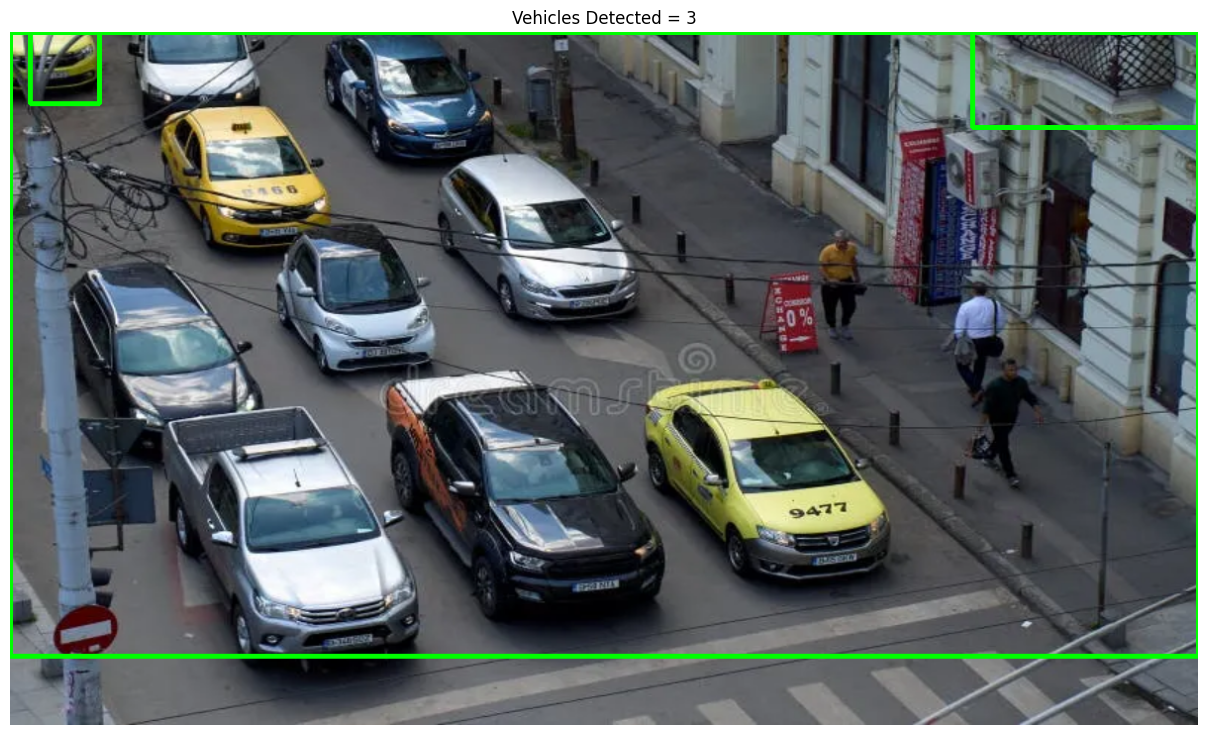

Total Vehicles Detected = 3


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

uploaded = files.upload()
img_path = list(uploaded.keys())[0]

img = cv2.imread(img_path)

img = cv2.resize(img, (1200, 700))

output = img.copy()

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

blur = cv2.GaussianBlur(gray, (5,5), 0)

edges = cv2.Canny(blur, 50, 150)

kernel = np.ones((3,3), np.uint8)
dilated = cv2.dilate(edges, kernel, iterations=2)

contours, _ = cv2.findContours(
    dilated,
    cv2.RETR_EXTERNAL,
    cv2.CHAIN_APPROX_SIMPLE
)

count = 0

for cnt in contours:

    area = cv2.contourArea(cnt)

    if area > 3000:

        x,y,w,h = cv2.boundingRect(cnt)

        ratio = w / h

        if 0.8 < ratio < 3.5:
            count += 1

            cv2.rectangle(output, (x,y), (x+w,y+h), (0,255,0), 3)
            cv2.putText(output, f"Car {count}",
                        (x,y-5),
                        cv2.FONT_HERSHEY_SIMPLEX,
                        0.7,
                        (255,0,0),
                        2)

plt.figure(figsize=(16,9))
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.title(f"Vehicles Detected = {count}")
plt.axis("off")
plt.show()

print("Total Vehicles Detected =", count)

In [7]:
traffic_data = {
    'vehicles':[5,10,15,25,35,45,60,75,90,110],
    'hour':[6,7,8,9,10,11,17,18,19,20],
    'day':[1,1,1,1,1,1,1,1,1,1],
    'traffic_level':[0,0,0,1,1,1,2,2,2,2]
}


df = pd.DataFrame(traffic_data)

df

,vehicles,hour,day,traffic_level
0,5,6,1,0
1,10,7,1,0
2,15,8,1,0
3,25,9,1,1
4,35,10,1,1
5,45,11,1,1
6,60,17,1,2
7,75,18,1,2
8,90,19,1,2
9,110,20,1,2


In [8]:
X = df[['vehicles','hour','day']]
y = df['traffic_level']

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X,y)

RandomForestClassifier(random_state=42)

In [9]:
hour = 18
day = 1

prediction = rf.predict([[count, hour, day]])[0]

levels = {
    0:"Low Traffic",
    1:"Medium Traffic",
    2:"High Traffic"
}

print("Predicted Traffic Status =", levels[prediction])

Predicted Traffic Status = High Traffic


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


In [10]:
from sklearn.metrics import accuracy_score

pred_train = rf.predict(X)
print("Model Accuracy =", accuracy_score(y, pred_train)*100, "%")

Model Accuracy = 100.0 %


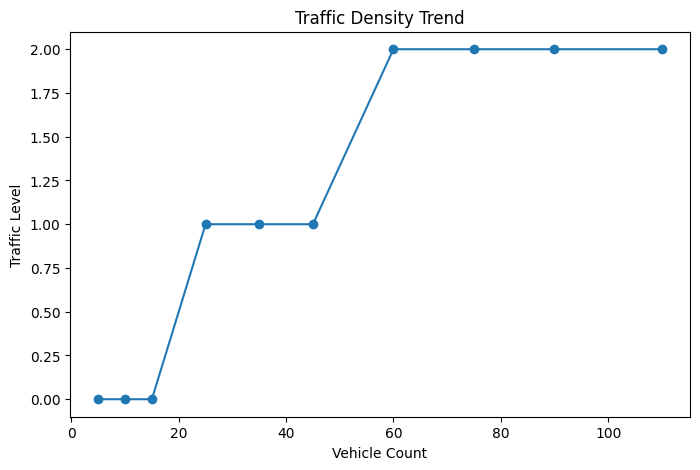

In [11]:
plt.figure(figsize=(8,5))
plt.plot(df['vehicles'], df['traffic_level'], marker='o')
plt.xlabel("Vehicle Count")
plt.ylabel("Traffic Level")
plt.title("Traffic Density Trend")
plt.show()

In [12]:
pollution_data = {
    'vehicles':[10,20,30,40,50,60,70,80,90,100],
    'temperature':[25,26,27,28,29,30,31,32,33,34],
    'AQI':[40,52,60,72,85,95,110,125,140,155]
}

pollution_df = pd.DataFrame(pollution_data)

pollution_df

,vehicles,temperature,AQI
0,10,25,40
1,20,26,52
2,30,27,60
3,40,28,72
4,50,29,85
5,60,30,95
6,70,31,110
7,80,32,125
8,90,33,140
9,100,34,155


In [13]:
X_pollution = pollution_df[['vehicles','temperature']]
y_pollution = pollution_df['AQI']

lr = LinearRegression()
lr.fit(X_pollution, y_pollution)

LinearRegression()

In [14]:
temp = 32

predicted_aqi = lr.predict([[count, temp]])[0]

print("Predicted AQI =", round(predicted_aqi,2))

Predicted AQI = 28.19


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [15]:
if predicted_aqi <= 50:
    status = "Good"
elif predicted_aqi <= 100:
    status = "Moderate"
elif predicted_aqi <= 150:
    status = "Unhealthy for Sensitive Groups"
else:
    status = "Unhealthy"

print("Air Quality Status =", status)

Air Quality Status = Good


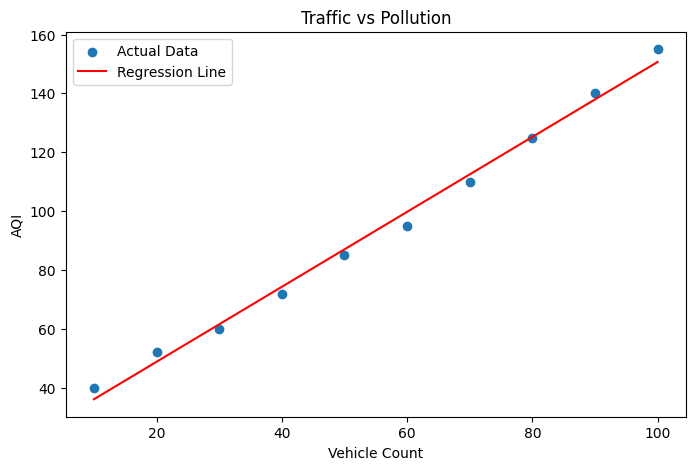

In [16]:
plt.figure(figsize=(8,5))
plt.scatter(pollution_df['vehicles'], pollution_df['AQI'], label="Actual Data")
plt.plot(pollution_df['vehicles'],
         lr.predict(X_pollution),
         color='red',
         label="Regression Line")

plt.xlabel("Vehicle Count")
plt.ylabel("AQI")
plt.title("Traffic vs Pollution")
plt.legend()
plt.show()

In [17]:
accident_data = {
    'traffic_level':[0,1,2,2,1,0,2,1,0,2],
    'rain':[0,0,1,1,0,0,1,1,0,1],
    'night':[0,1,1,0,1,0,1,0,0,1],
    'speed':[40,55,70,80,60,35,90,65,30,95],
    'risk':[0,1,2,2,1,0,2,1,0,2]
}

accident_df = pd.DataFrame(accident_data)

accident_df

,traffic_level,rain,night,speed,risk
0,0,0,0,40,0
1,1,0,1,55,1
2,2,1,1,70,2
3,2,1,0,80,2
4,1,0,1,60,1
5,0,0,0,35,0
6,2,1,1,90,2
7,1,1,0,65,1
8,0,0,0,30,0
9,2,1,1,95,2


In [18]:
X_acc = accident_df[['traffic_level','rain','night','speed']]
y_acc = accident_df['risk']

dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_acc, y_acc)

DecisionTreeClassifier(random_state=42)

In [19]:
traffic_now = prediction
rain_now = 1
night_now = 1
speed_now = 75

risk_pred = dt.predict([[traffic_now, rain_now, night_now, speed_now]])[0]

risk_levels = {
    0:"Low Risk",
    1:"Medium Risk",
    2:"High Risk"
}

print("Accident Risk =", risk_levels[risk_pred])

Accident Risk = High Risk


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


In [20]:
from sklearn.metrics import accuracy_score

train_pred = dt.predict(X_acc)

print("Model Accuracy =", accuracy_score(y_acc, train_pred)*100, "%")

Model Accuracy = 100.0 %


In [21]:
final_report = pd.DataFrame({
    "Metric":[
        "Vehicles Detected",
        "Traffic Level",
        "Predicted AQI",
        "Air Quality Status",
        "Accident Risk"
    ],

    "Result":[
        count,
        levels[prediction],
        round(predicted_aqi,2),
        status,
        risk_levels[risk_pred]
    ]
})

final_report

,Metric,Result
0,Vehicles Detected,3
1,Traffic Level,High Traffic
2,Predicted AQI,28.19
3,Air Quality Status,Good
4,Accident Risk,High Risk


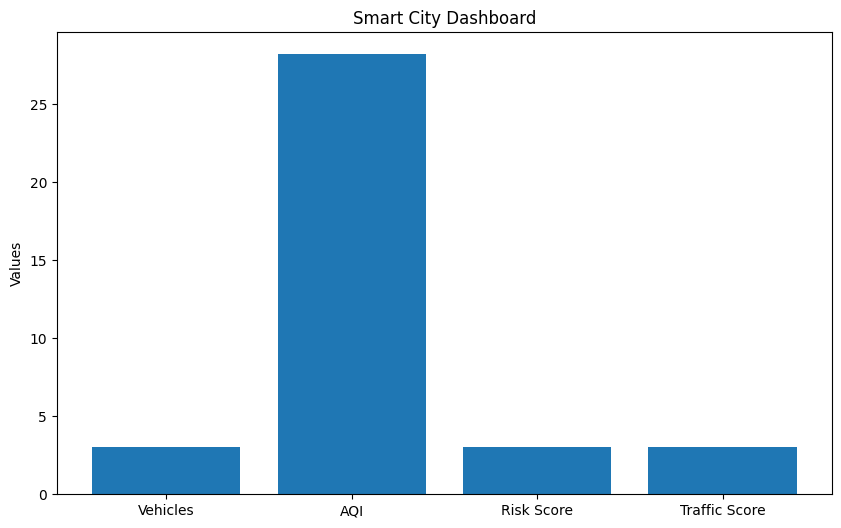

In [22]:
dashboard_values = [
    count,
    predicted_aqi,
    risk_pred + 1,
    prediction + 1
]

dashboard_labels = [
    "Vehicles",
    "AQI",
    "Risk Score",
    "Traffic Score"
]

plt.figure(figsize=(10,6))
plt.bar(dashboard_labels, dashboard_values)

plt.title("Smart City Dashboard")
plt.ylabel("Values")
plt.show()

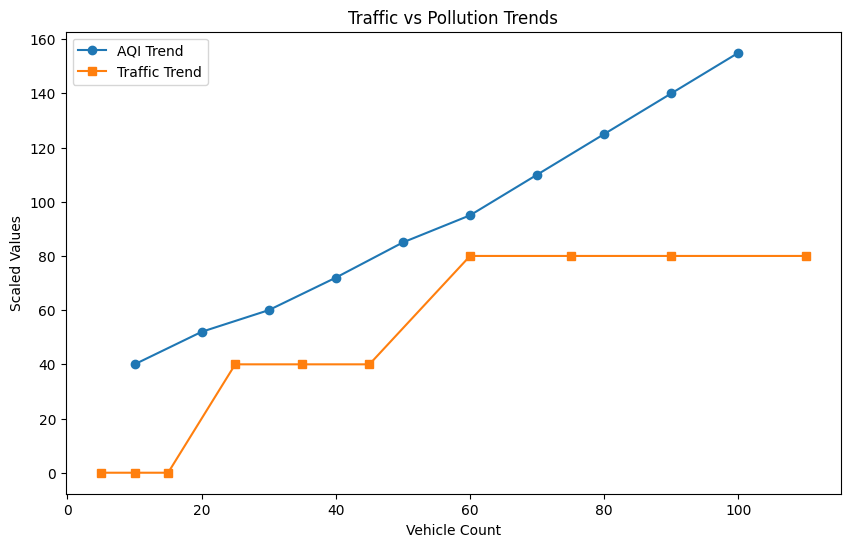

In [23]:
plt.figure(figsize=(10,6))

plt.plot(pollution_df['vehicles'],
         pollution_df['AQI'],
         marker='o',
         label="AQI Trend")

plt.plot(df['vehicles'],
         df['traffic_level']*40,
         marker='s',
         label="Traffic Trend")

plt.xlabel("Vehicle Count")
plt.ylabel("Scaled Values")
plt.title("Traffic vs Pollution Trends")
plt.legend()
plt.show()

In [24]:
score = 100

if prediction == 2:
    score -= 30
elif prediction == 1:
    score -= 15

if predicted_aqi > 150:
    score -= 30
elif predicted_aqi > 100:
    score -= 15

if risk_pred == 2:
    score -= 30
elif risk_pred == 1:
    score -= 15

print("Overall Smart City Score =", score, "/100")

Overall Smart City Score = 40 /100


In [25]:
if score >= 80:
    print("City Zone Performing Well")
elif score >= 50:
    print("Needs Improvement")
else:
    print("Critical Zone - Immediate Action Required")

Critical Zone - Immediate Action Required


In [26]:
!pip install folium -q

In [27]:
import folium
from IPython.display import display

In [28]:
city_map = folium.Map(
    location=[19.0860,72.8890],
    zoom_start=12
)

city_map

In [29]:
folium.Marker(
    [19.0860,72.8890],
    popup="Heavy Traffic Zone",
    icon=folium.Icon(color="red", icon="info-sign")
).add_to(city_map)

folium.Marker(
    [19.0860,72.8890],
    popup="Medium Traffic",
    icon=folium.Icon(color="orange")
).add_to(city_map)

city_map

In [30]:
folium.Circle(
    radius=500,
    location=[19.0720,72.8850],
    popup="High Accident Risk",
    color="red",
    fill=True
).add_to(city_map)

city_map

In [31]:
folium.Circle(
    radius=700,
    location=[19.0810,72.8700],
    popup="High Pollution AQI Zone",
    color="purple",
    fill=True
).add_to(city_map)

city_map

In [32]:
city_map.save("smart_city_map.html")
print("Map Saved Successfully")

Map Saved Successfully


In [ ]:
from google.colab import files
files.download("smart_city_map.html")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>